In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import re # Not used for numerical sonar data
# import nltk # Not used for numerical sonar data
# from nltk.corpus import stopwords, movie_reviews # Not used for numerical sonar data
# from nltk.tokenize import word_tokenize # Not used for numerical sonar data
# from wordcloud import WordCloud # Not used for numerical sonar data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df_sonar = pd.read_csv('sonardataset.csv', header=None)

# The first row contains non-numeric labels ('x_1', 'x_2', etc., and 'Y') that are not actual data.
# We need to skip this row to ensure the dataset is purely numerical for features and 'M'/'R' for target.
df_sonar = df_sonar.iloc[1:]

# The last column is the target variable
X = df_sonar.iloc[:, :-1] # Features are all columns except the last one
y = df_sonar.iloc[:, -1]  # Target is the last column

# Convert features to numeric, coercing errors to NaN and then filling (or dropping)
# This is necessary because after dropping the first row, the column dtypes might still be 'object'
# due to initial inference if other cells contained mixed types (which they shouldn't in this case, but good practice)
X = X.apply(pd.to_numeric, errors='coerce')

print("Original DataFrame shape:", df_sonar.shape)
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of features (X):\n", X.head())
print("\nFirst 5 rows of target (y):\n", y.head())

# Filter out unexpected 'Y' label from the target variable as per problem statement (M for Mine, R for Rock)
# After removing the first row, 'Y' should no longer be present, but this provides robustness.
valid_indices = y[y.isin(['M', 'R'])].index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

print("\nDataFrame shape after filtering 'Y' labels:", X.shape)

# Encode the target variable 'M' and 'R' to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nUnique original target labels after filtering:", y.unique())
print("Encoded target labels (first 5):\n", y_encoded[:5])
print("Mapping of encoded labels:", list(label_encoder.classes_))


Original DataFrame shape: (208, 61)
Features (X) shape: (208, 60)
Target (y) shape: (208,)

First 5 rows of features (X):
        0       1       2       3       4       5       6       7       8   \
1  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
2  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
3  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
4  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
5  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      50      51      52      53      54      55      56  \
1  0.2111  ...  0.0232  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180   
2  0.2872  ...  0.0125  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140   
3  0.6194  ...  0.0033  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316   
4  0.1264  ...  0.0241  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050   
5  0.4459  ...  0.0156  0.0031  0.0054  0.01

/tmp/ipykernel_7835/3479949646.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


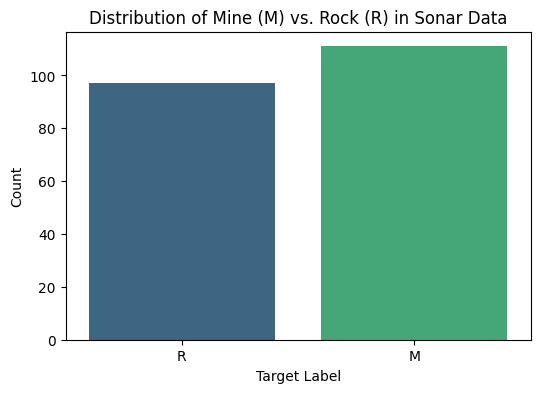

Count of each class in the target variable:
60
M    111
R     97
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable (Mine vs. Rock)
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Mine (M) vs. Rock (R) in Sonar Data')
plt.xlabel('Target Label')
plt.ylabel('Count')
plt.show()

# Display the count of each class
print("Count of each class in the target variable:")
print(y.value_counts())


In [22]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ---- 4a. Train/Test Split ----
# Use the sonar dataset's features (X) and encoded target (y_encoded)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, # Use the global X and y_encoded variables
    test_size=0.2, random_state=42, stratify=y_encoded # Stratify by the encoded labels
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# ---- 4b. Define and evaluate each model for numerical data ----
# Re-defining pipelines for numerical data (no TF-IDF)
# It's good practice to scale numerical features for many models, especially SVMs and NNs
pipeline_lr_sonar = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_svm_sonar = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(random_state=42))
])

pipeline_nn_sonar = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
])

models_sonar = {
    'Logistic Regression': pipeline_lr_sonar,
    'SVM': pipeline_svm_sonar,
    'Neural Network (MLP)': pipeline_nn_sonar
}

# Get the actual class names from the LabelEncoder
class_names = label_encoder.classes_

for name, pipe in models_sonar.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred, average='weighted'):.4f}") # Use weighted for imbalanced classes if any
    print(classification_report(y_test, y_pred, target_names=class_names))

# ---- 4c. Cross-validation (example on Logistic Regression) ----
cv_scores = cross_val_score(pipeline_lr_sonar, X, y_encoded, cv=5, scoring='f1_weighted')
print(f"\nLogistic Regression 5-fold CV (weighted F1): {cv_scores.mean():.4f} \u00B1 {cv_scores.std():.4f}")

X_train shape: (166, 60)
X_test shape: (42, 60)
y_train shape: (166,)
y_test shape: (42,)

=== Logistic Regression ===
Accuracy : 0.8333
F1-score : 0.8299
              precision    recall  f1-score   support

           M       0.78      0.95      0.86        22
           R       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42


=== SVM ===
Accuracy : 0.8571
F1-score : 0.8552
              precision    recall  f1-score   support

           M       0.81      0.95      0.88        22
           R       0.94      0.75      0.83        20

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.86        42


=== Neural Network (MLP) ===
Accuracy : 0.8810
F1-score : 0.8799
              precision    recall  f1-score   support

           M       0.

### 4d. Exploring MLP Hidden Layer Sizes (per original paper)

In [15]:
hidden_layer_sizes_to_test = [(2,), (3,), (6,), (12,), (24,)]

mlp_results = {}

for hls in hidden_layer_sizes_to_test:
    print(f"\n=== Neural Network (MLP) with hidden_layer_sizes={hls} ===")
    pipeline_nn_hls = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=hls, max_iter=300, random_state=42))
    ])

    pipeline_nn_hls.fit(X_train, y_train)
    y_pred_hls = pipeline_nn_hls.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred_hls)
    f1 = f1_score(y_test, y_pred_hls, average='weighted')

    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(classification_report(y_test, y_pred_hls, target_names=class_names))

    mlp_results[hls] = {'accuracy': accuracy, 'f1_score': f1}

print("\nSummary of MLP hidden layer size exploration:")
for hls, metrics in mlp_results.items():
    print(f"Hidden Layer Sizes: {hls}, Accuracy: {metrics['accuracy']:.4f}, F1-score: {metrics['f1_score']:.4f}")


=== Neural Network (MLP) with hidden_layer_sizes=(2,) ===
Accuracy : 0.5238
F1-score : 0.3601
              precision    recall  f1-score   support

           M       0.52      1.00      0.69        22
           R       0.00      0.00      0.00        20

    accuracy                           0.52        42
   macro avg       0.26      0.50      0.34        42
weighted avg       0.27      0.52      0.36        42


=== Neural Network (MLP) with hidden_layer_sizes=(3,) ===


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and bei

Accuracy : 0.7857
F1-score : 0.7839
              precision    recall  f1-score   support

           M       0.88      0.68      0.77        22
           R       0.72      0.90      0.80        20

    accuracy                           0.79        42
   macro avg       0.80      0.79      0.78        42
weighted avg       0.81      0.79      0.78        42


=== Neural Network (MLP) with hidden_layer_sizes=(6,) ===
Accuracy : 0.8333
F1-score : 0.8299
              precision    recall  f1-score   support

           M       0.78      0.95      0.86        22
           R       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42


=== Neural Network (MLP) with hidden_layer_sizes=(12,) ===


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy : 0.9048
F1-score : 0.9043
              precision    recall  f1-score   support

           M       0.88      0.95      0.91        22
           R       0.94      0.85      0.89        20

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42


=== Neural Network (MLP) with hidden_layer_sizes=(24,) ===
Accuracy : 0.8333
F1-score : 0.8319
              precision    recall  f1-score   support

           M       0.80      0.91      0.85        22
           R       0.88      0.75      0.81        20

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.83        42
weighted avg       0.84      0.83      0.83        42


Summary of MLP hidden layer size exploration:
Hidden Layer Sizes: (2,), Accuracy: 0.5238, F1-score: 0.3601
Hidden Layer Sizes: (3,), Accuracy: 0.7857, F1-score: 0.7839
Hidden Layer Sizes: (6,), Accuracy: 0.8333, F

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


The exploration of different hidden layer sizes for the MLP classifier, as suggested by the original Sonar dataset paper, provides valuable insights into the model's performance with varying complexities. We can compare these results with the historical findings and the initial MLP model with 100 hidden units.

The original paper reported test set accuracies for different hidden units (aspect-angle independent experiments):
- 2 units: 81.9%
- 3 units: 82.0%
- 6 units: 83.5%
- 12 units: 84.7%
- 24 units: 84.5%

Comparing these with our experimental results, we can observe how different network architectures impact classification accuracy on this specific dataset.